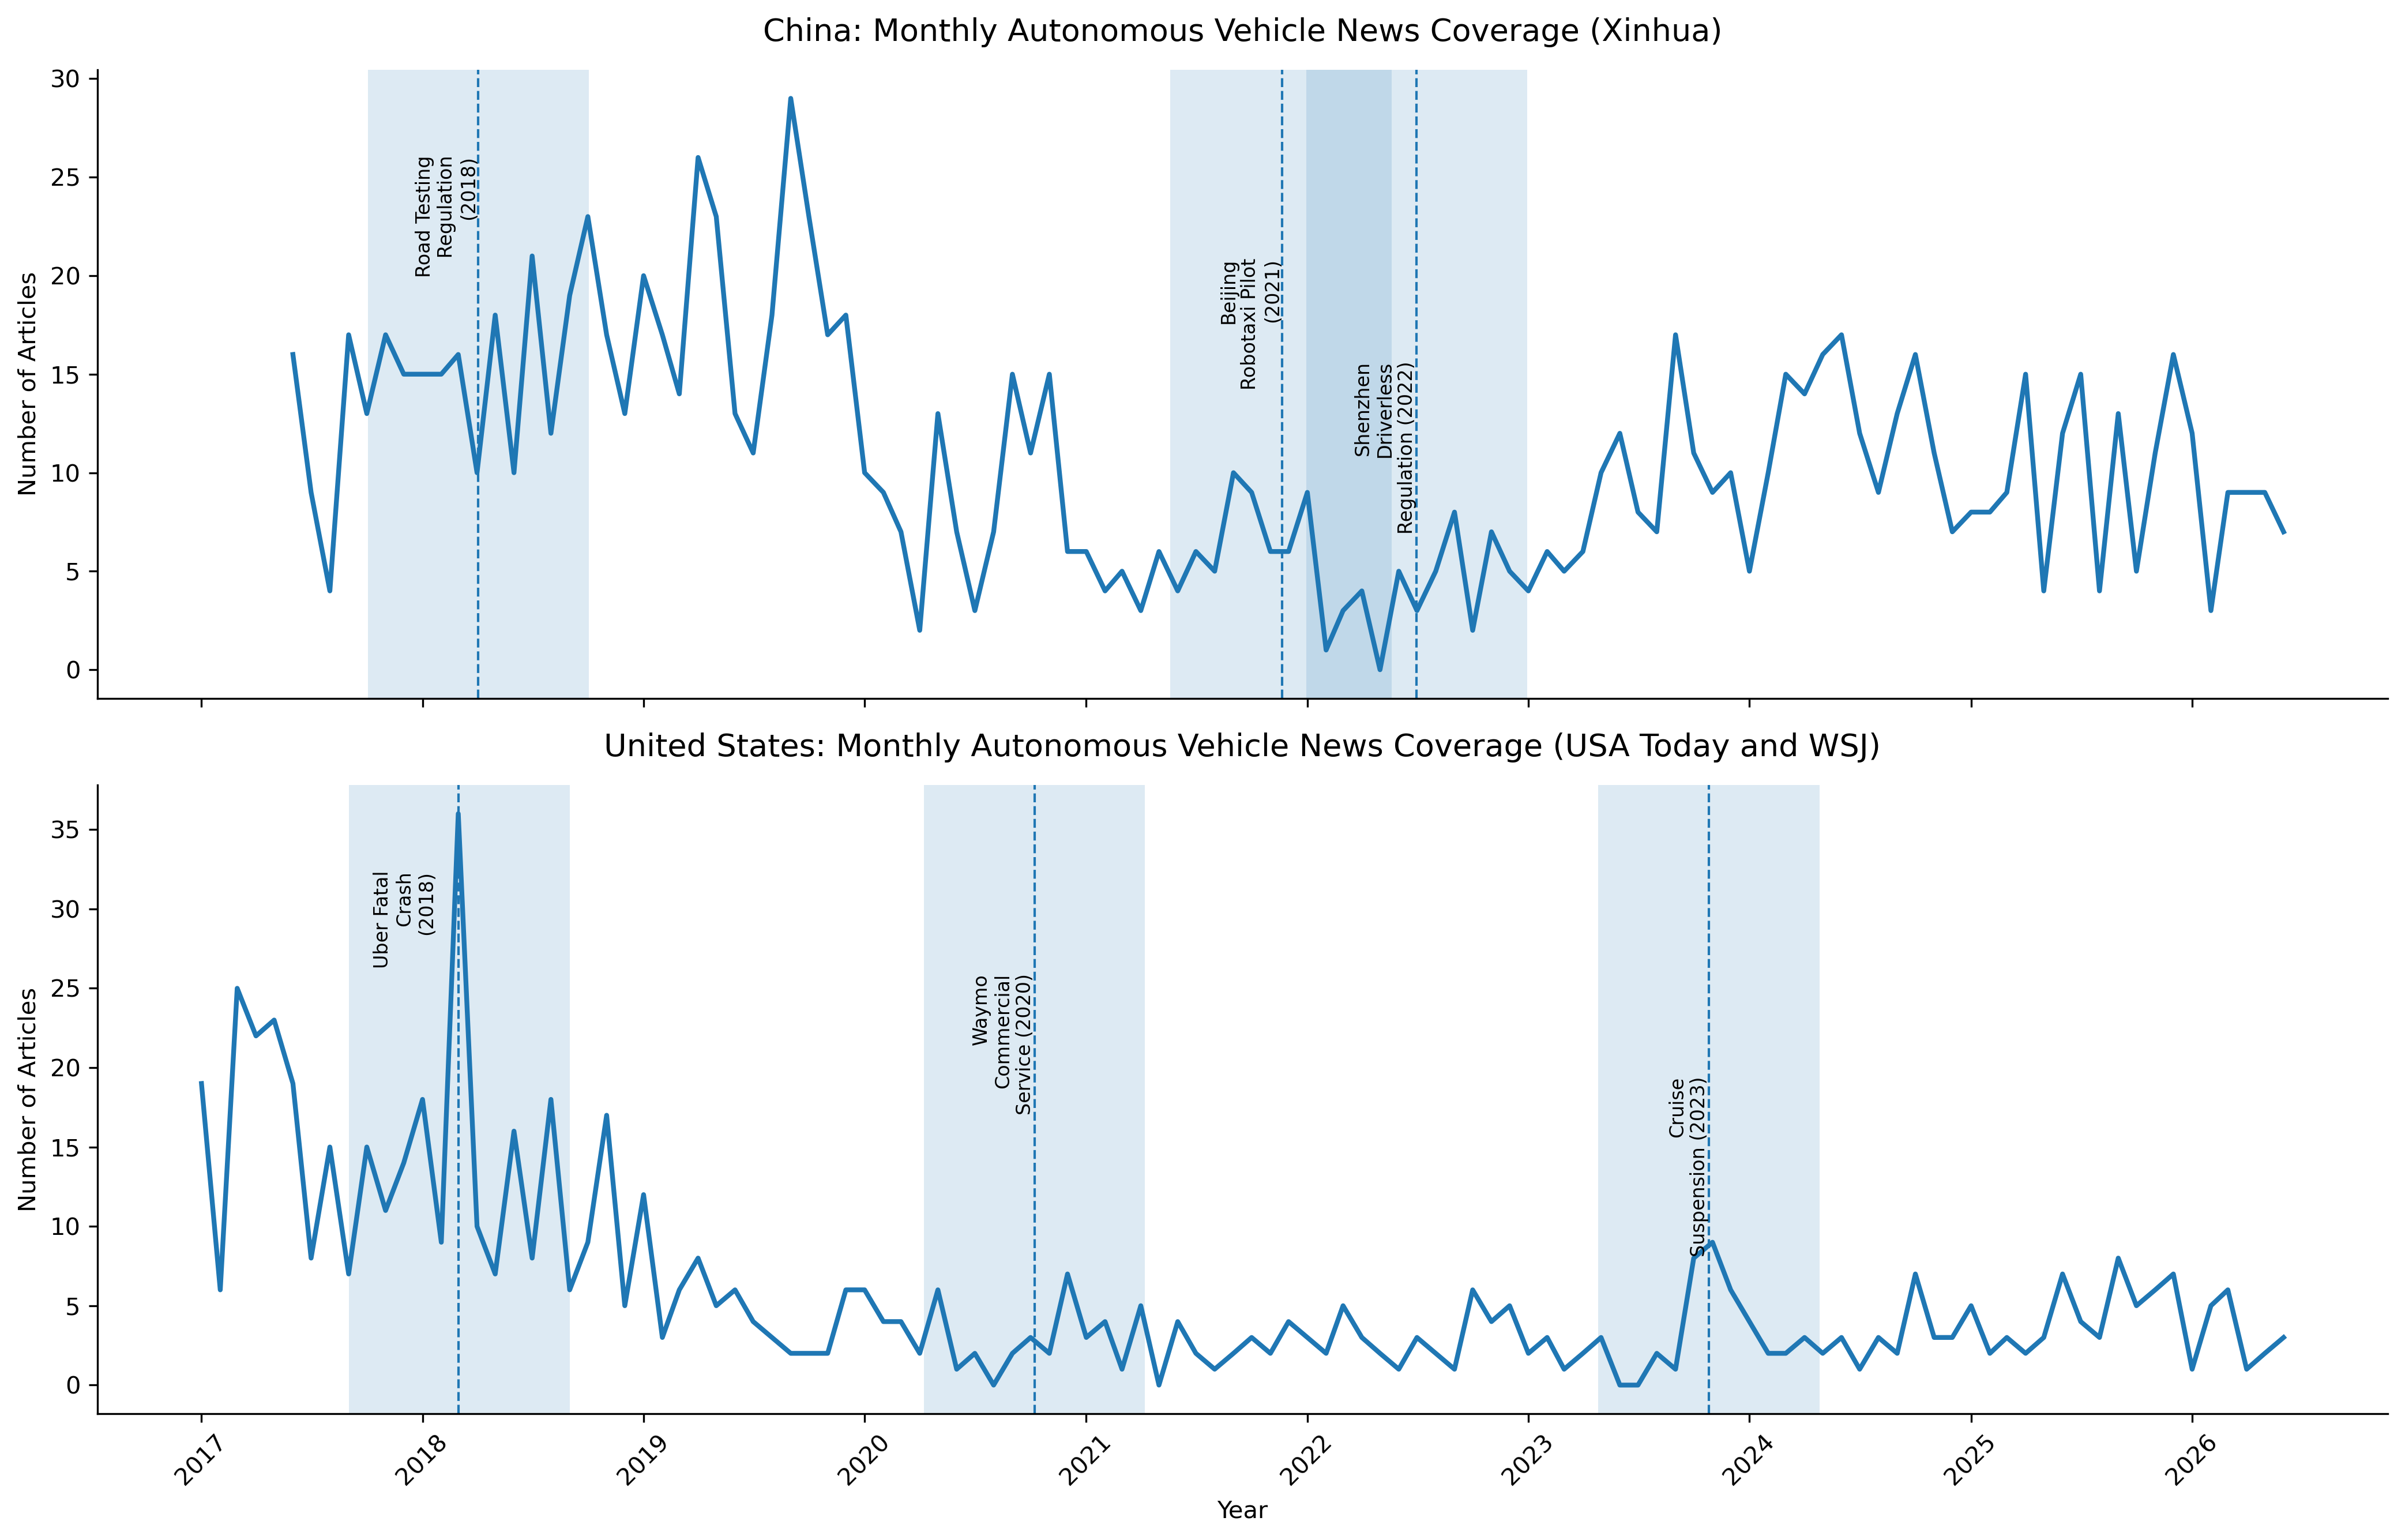

Figure saved to: /Users/yurujia/Desktop/event_monthly_AV_coverage_by_country.png


In [ ]:
# %%
# ============================================================
# Event-based Analysis
# Figure X: Monthly AV News Coverage with Selected Events
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

DATA_PATH = Path(
    "/Users/yurujia/Desktop/Dissertation Data/final_AV_media_analysis_dataset.xlsx"
)

df = pd.read_excel(DATA_PATH)


# ------------------------------------------------------------
# Date preparation
# ------------------------------------------------------------

df["date_fixed"] = pd.to_datetime(df["date_fixed"])

df["year_month"] = (
    df["date_fixed"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


# ------------------------------------------------------------
# Define event dates (verified dates - unchanged)
# ------------------------------------------------------------

china_events = {
    "Road Testing\n Regulation\n(2018)": "2018-04-03",
    "Beijing\nRobotaxi Pilot\n(2021)": "2021-11-25",
    "Shenzhen\nDriverless\nRegulation (2022)": "2022-06-30"
}


us_events = {
    "Uber Fatal\nCrash\n(2018)\n": "2018-03-18",
    "Waymo\nCommercial\nService (2020)": "2020-10-08",
    "Cruise\nSuspension (2023)": "2023-10-24"
}


china_events = {
    k: pd.to_datetime(v)
    for k, v in china_events.items()
}


us_events = {
    k: pd.to_datetime(v)
    for k, v in us_events.items()
}



# ------------------------------------------------------------
# Monthly aggregation function
# ------------------------------------------------------------

def monthly_articles(data):

    monthly = (
        data
        .groupby("year_month")
        .size()
        .reset_index(name="article_count")
    )

    full_months = pd.date_range(
        start=data["year_month"].min(),
        end=data["year_month"].max(),
        freq="MS"
    )

    monthly = (
        monthly
        .set_index("year_month")
        .reindex(full_months, fill_value=0)
        .rename_axis("year_month")
        .reset_index()
    )

    return monthly



# ------------------------------------------------------------
# Prepare country datasets
# ------------------------------------------------------------

china_df = df[
    df["country"] == "China"
].copy()


us_df = df[
    df["country"] == "USA"
].copy()


china_monthly = monthly_articles(china_df)

us_monthly = monthly_articles(us_df)



# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def plot_events(
    ax,
    monthly_data,
    events,
    title
):

    ax.plot(
        monthly_data["year_month"],
        monthly_data["article_count"],
        linewidth=2
    )


    y_max = monthly_data["article_count"].max()


    for i, (event, date) in enumerate(events.items()):

        # Six-month event window
        start = date - pd.DateOffset(months=6)
        end = date + pd.DateOffset(months=6)

        ax.axvspan(
            start,
            end,
            alpha=0.15
        )


        # Event date
        ax.axvline(
            date,
            linestyle="--",
            linewidth=1
        )


        # Event label
        ax.text(
            date,
            y_max * (0.90 - i * 0.18),
            event,
            rotation=90,
            fontsize=8,
            verticalalignment="top",
            horizontalalignment="right"
        )


    ax.set_title(
        title,
        fontsize=13,
        pad=12
    )

    ax.set_ylabel(
        "Number of Articles"
    )


    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    dpi=300,
    sharex=True
)


# China

plot_events(
    axes[0],
    china_monthly,
    china_events,
    "China: Monthly Autonomous Vehicle News Coverage (Xinhua)"
)



# US

plot_events(
    axes[1],
    us_monthly,
    us_events,
    "United States: Monthly Autonomous Vehicle News Coverage (USA Today and WSJ)"
)


axes[1].set_xlabel(
    "Year"
)



# ------------------------------------------------------------
# Date formatting
# ------------------------------------------------------------

for ax in axes:

    ax.xaxis.set_major_locator(
        mdates.YearLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )


plt.xticks(rotation=45)


plt.tight_layout()



# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

OUTPUT_PATH = Path(
    "/Users/yurujia/Desktop/event_monthly_AV_coverage_by_country.png"
)


plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Figure saved to: {OUTPUT_PATH}"
)

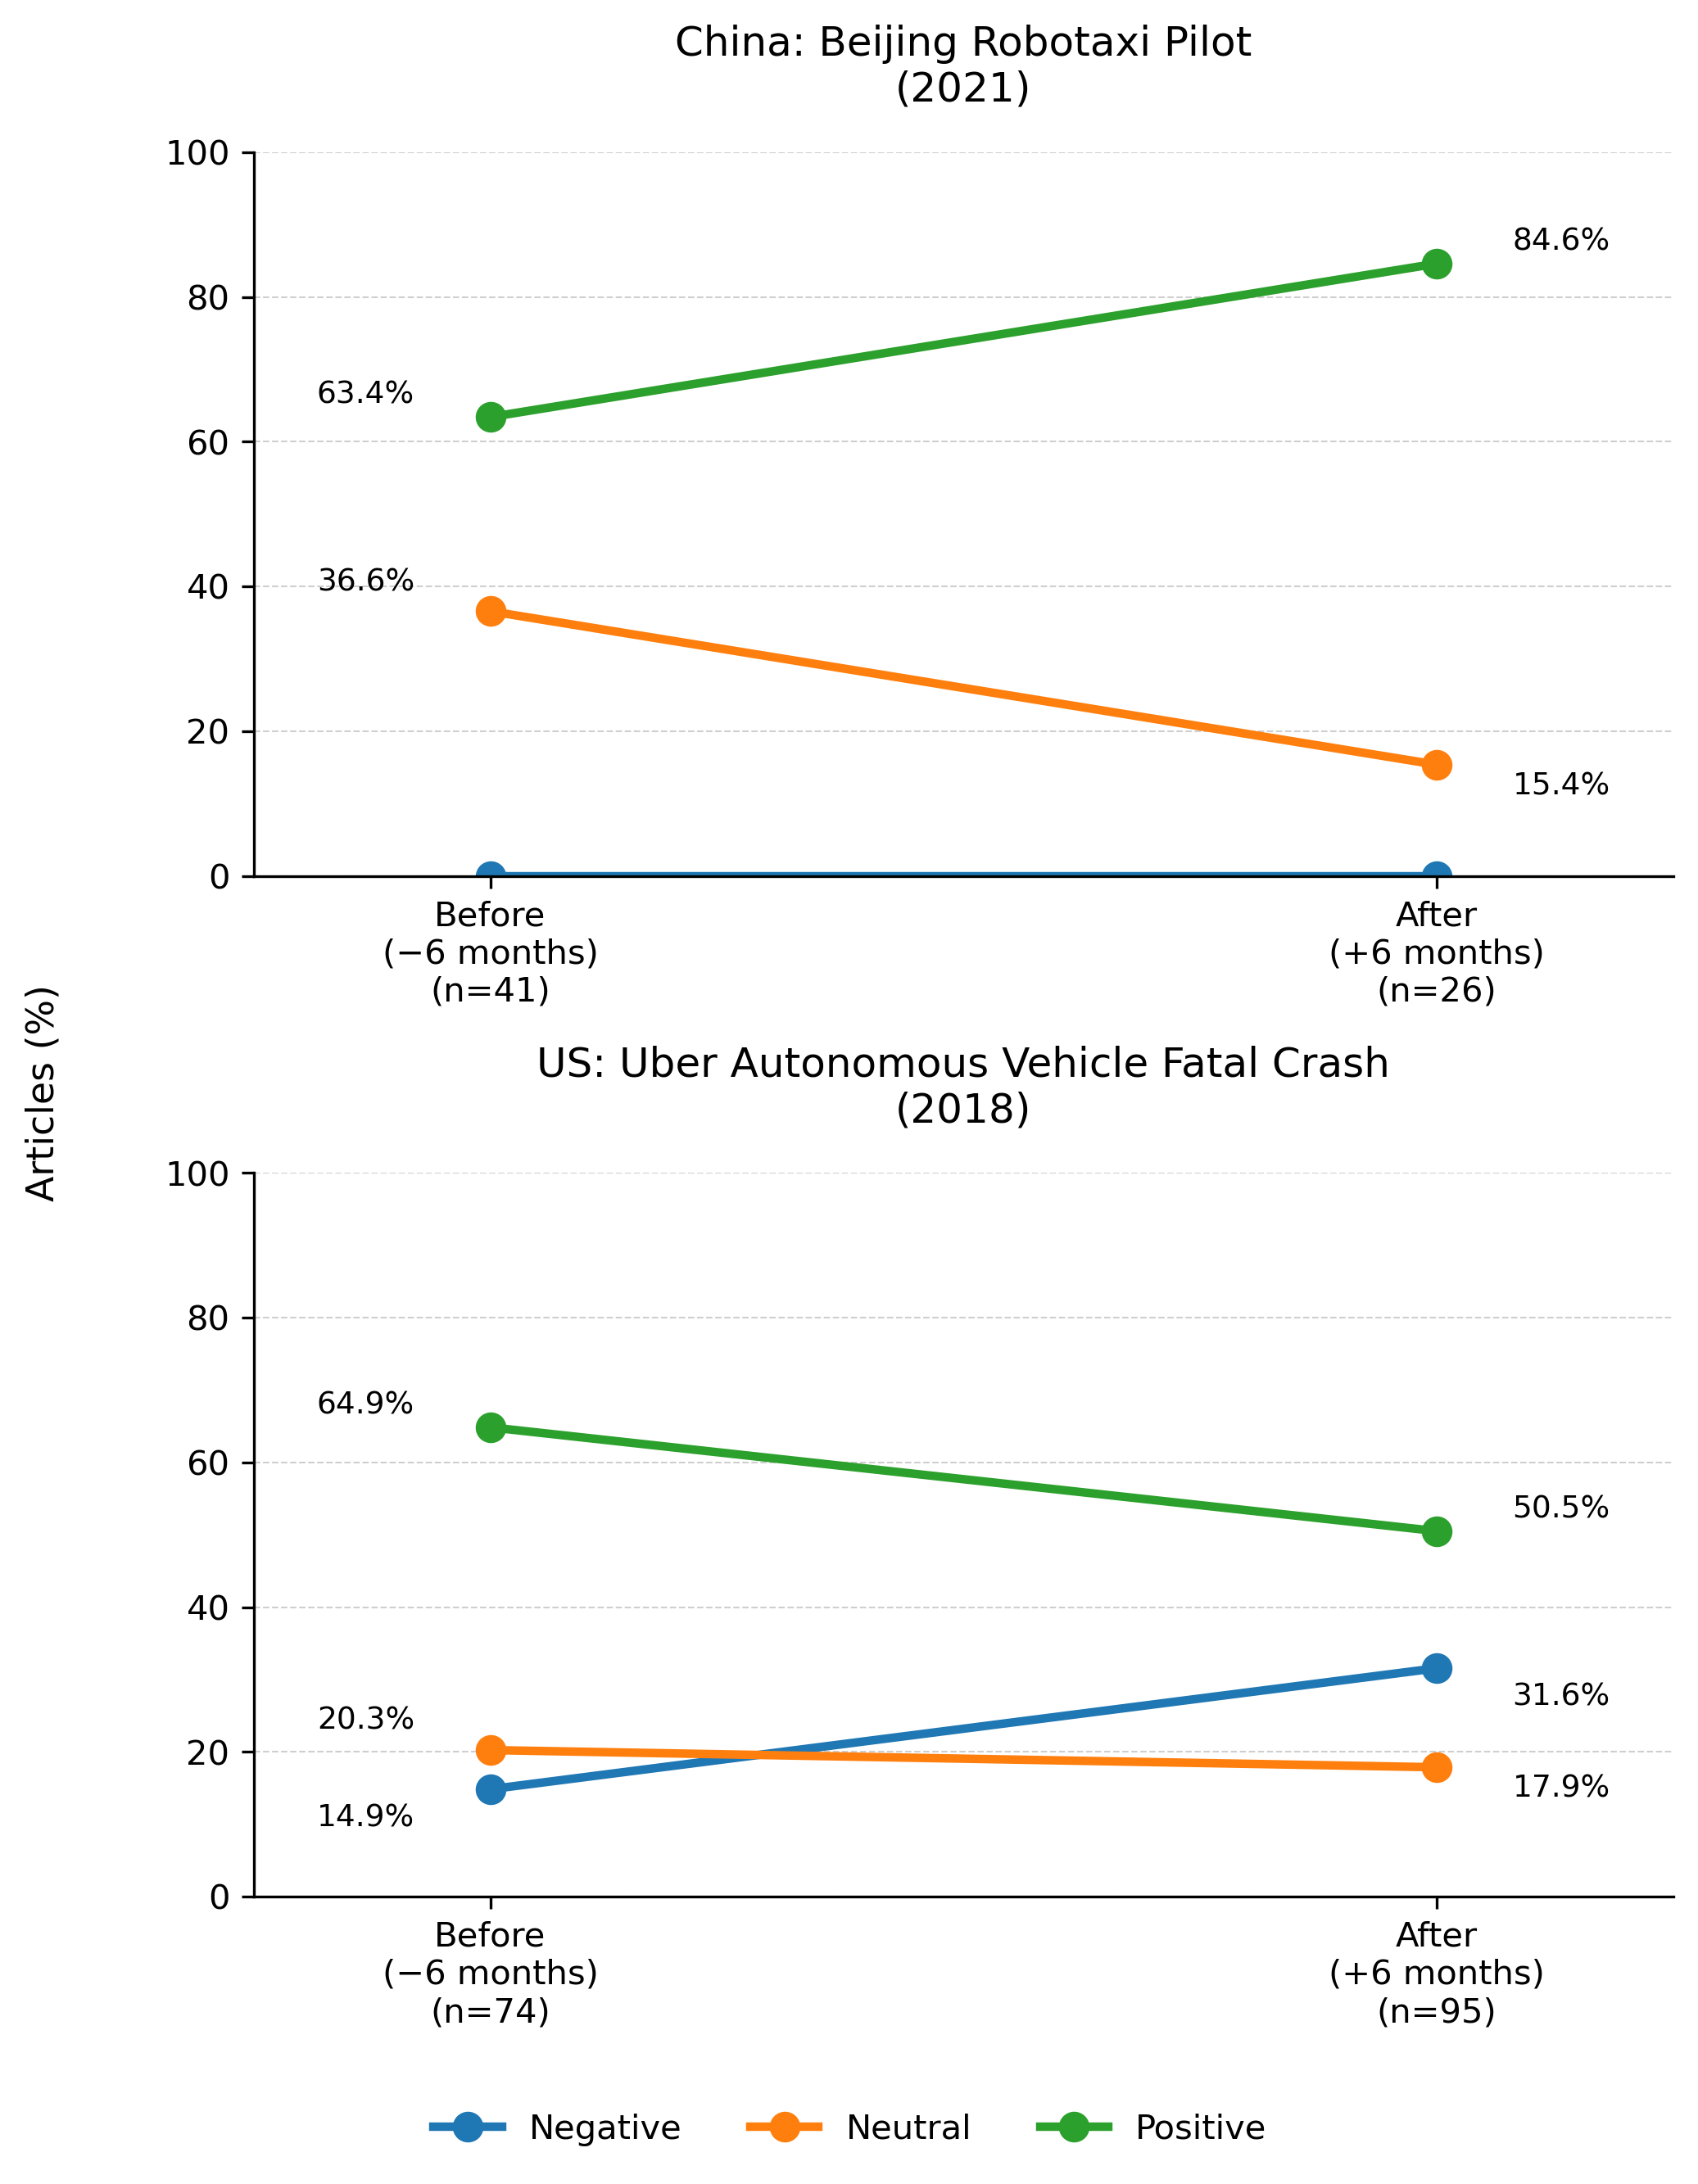

Saved to: /Users/yurujia/Desktop/event_sentiment_slope_chart_final.png


In [49]:
# ------------------------------------------------------------
# Plot (final publication version)
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7, 9),
    dpi=300,
    sharey=True
)


sentiment_names = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}


sentiment_order = [
    "Negative",
    "Neutral",
    "Positive"
]


# Fixed sentiment colours

sentiment_colors = {
    "Negative": "tab:blue",
    "Neutral": "tab:orange",
    "Positive": "tab:green"
}



# label offsets

before_offsets = {
    "Negative": -4,
    "Neutral": 4,
    "Positive": 3
}


after_offsets = {
    "Negative": -4,
    "Neutral": -3,
    "Positive": 3
}



legend_handles = []
legend_labels = []



for ax, (event, result) in zip(
    axes,
    results.items()
):

    data = (
        result["data"]
        .rename(index=sentiment_names)
    )



    for sentiment in sentiment_order:


        before = data.loc[
            sentiment,
            "Before"
        ]

        after = data.loc[
            sentiment,
            "After"
        ]



        # -------------------------
        # Plot line
        # -------------------------

        line, = ax.plot(
            [0, 1],
            [before, after],
            marker="o",
            markersize=8,
            linewidth=2.5,
            color=sentiment_colors[sentiment],
            label=sentiment
        )



        if sentiment not in legend_labels:

            legend_handles.append(line)
            legend_labels.append(sentiment)



        # -------------------------
        # Labels
        # -------------------------

        # Remove 0% text labels,
        # but keep line and point

        if before >= 0.5:

            ax.text(
                -0.08,
                before + before_offsets[sentiment],
                f"{before:.1f}%",
                ha="right",
                va="center",
                fontsize=9
            )



        if after >= 0.5:

            ax.text(
                1.08,
                after + after_offsets[sentiment],
                f"{after:.1f}%",
                ha="left",
                va="center",
                fontsize=9
            )



    # -------------------------
    # Formatting
    # -------------------------

    ax.set_xlim(
        -0.25,
        1.25
    )


    ax.set_ylim(
        0,
        100
    )


    ax.set_xticks(
        [0, 1]
    )


    ax.set_xticklabels(
        [
            f"Before\n(−6 months)\n(n={result['n_before']})",
            f"After\n(+6 months)\n(n={result['n_after']})"
        ],
        fontsize=10
    )



    # Updated titles

    if "China" in event:

        ax.set_title(
            "China: Beijing Robotaxi Pilot\n(2021)",
            fontsize=12,
            pad=15
        )

    else:

        ax.set_title(
            "US: Uber Autonomous Vehicle Fatal Crash\n(2018)",
            fontsize=12,
            pad=15
        )



    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.6
    )



    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



# -------------------------
# Shared y-axis label
# -------------------------

fig.text(
    0.02,
    0.5,
    "Articles (%)",
    rotation="vertical",
    va="center",
    fontsize=11
)



# -------------------------
# Legend
# -------------------------

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)



plt.tight_layout(
    rect=[0.08, 0.06, 1, 1]
)



# -------------------------
# Save
# -------------------------

OUTPUT_PATH = Path(
    "/Users/yurujia/Desktop/event_sentiment_slope_chart_final.png"
)


plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved to: {OUTPUT_PATH}"
)

                            topic     Before      After  \
0       Technology and Innovation  53.658537  61.538462   
1  Business and Commercialisation  19.512195  23.076923   
2           Policy and Regulation  12.195122   3.846154   
3                 Safety and Risk   0.000000   0.000000   
4       Technology and Innovation  13.513514   6.315789   
5  Business and Commercialisation  58.108108  38.947368   
6           Policy and Regulation   2.702703   9.473684   
7                 Safety and Risk   1.351351  29.473684   

                                             Event  Before_n  After_n  
0            China: Beijing Robotaxi Pilot\n(2021)        41       26  
1            China: Beijing Robotaxi Pilot\n(2021)        41       26  
2            China: Beijing Robotaxi Pilot\n(2021)        41       26  
3            China: Beijing Robotaxi Pilot\n(2021)        41       26  
4  US: Uber Autonomous Vehicle Fatal Crash\n(2018)        74       95  
5  US: Uber Autonomous Vehicle Fatal

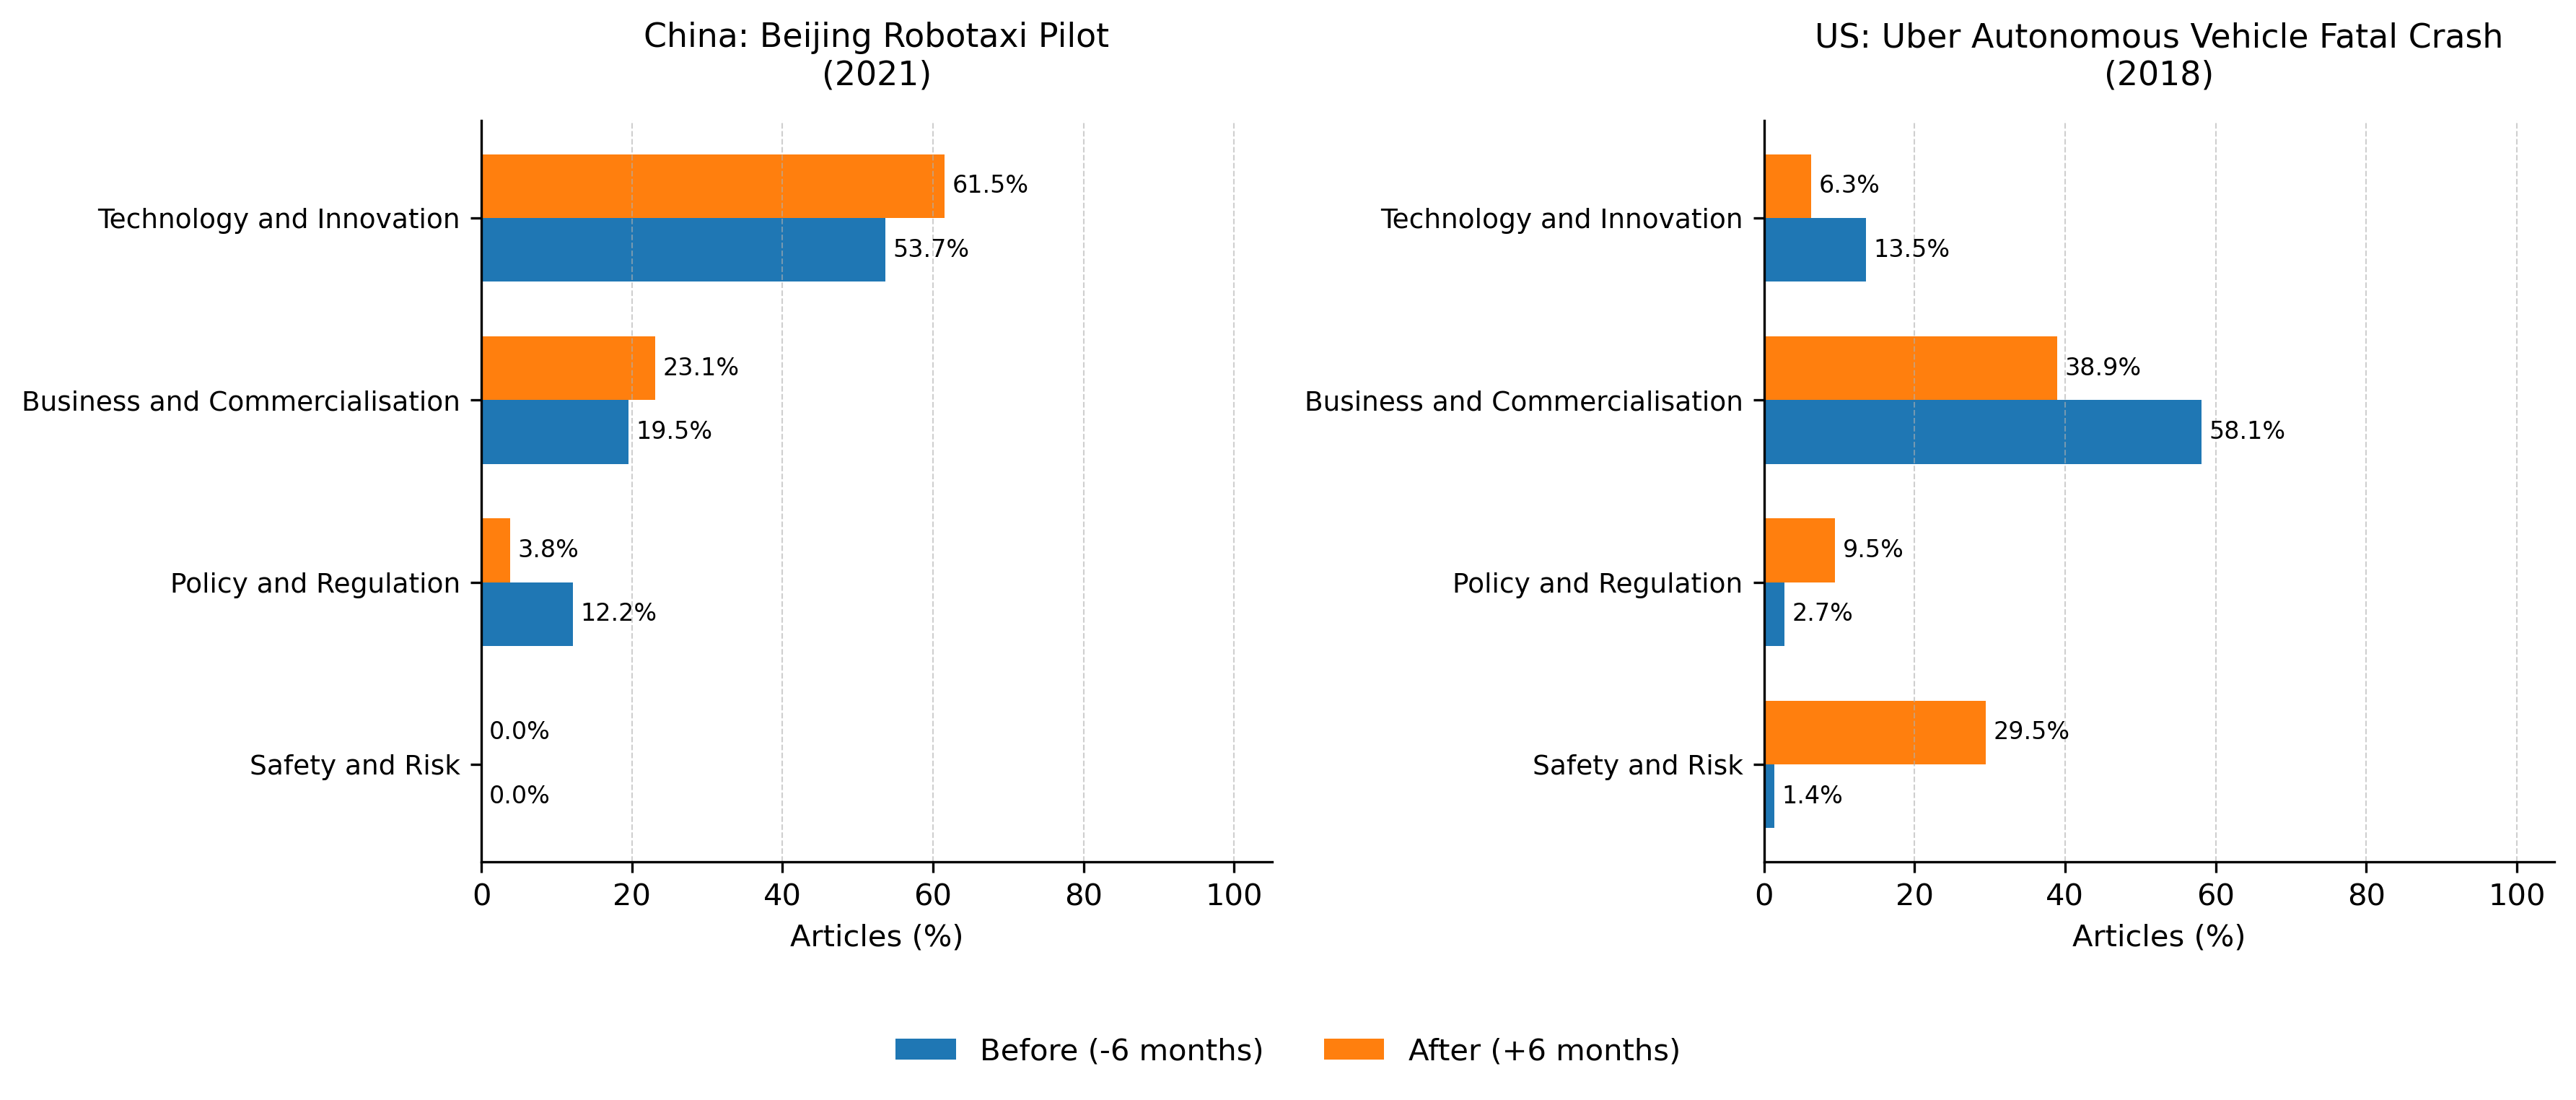

Figure saved: /Users/yurujia/Desktop/event_topic_framing_fixed_frames_with_labels.png


In [50]:
# %%
# ============================================================
# Event-based Topic Framing Analysis
# Fixed Core Frames Before and After Representative AV Events
# ============================================================


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

DATA_PATH = Path(
    "/Users/yurujia/Desktop/Dissertation Data/final_AV_media_analysis_dataset.xlsx"
)

df = pd.read_excel(DATA_PATH)



# ------------------------------------------------------------
# Prepare dates
# ------------------------------------------------------------

df["date_fixed"] = pd.to_datetime(
    df["date_fixed"],
    errors="coerce"
)



# ------------------------------------------------------------
# Events
# ------------------------------------------------------------

events = {

    "China: Beijing Robotaxi Pilot\n(2021)": {
        "country": "China",
        "date": "2021-11-20"
    },


    "US: Uber Autonomous Vehicle Fatal Crash\n(2018)": {
        "country": "USA",
        "date": "2018-03-01"
    }

}



for e in events:

    events[e]["date"] = pd.to_datetime(
        events[e]["date"]
    )



# ------------------------------------------------------------
# Fixed framing categories
# ------------------------------------------------------------

selected_topics = [
    "Technology and Innovation",
    "Business and Commercialisation",
    "Policy and Regulation",
    "Safety and Risk"
]



# ------------------------------------------------------------
# Extract topic distribution
# ------------------------------------------------------------

def get_event_topic_distribution(
    data,
    event_date
):


    before = data[
        (data["date_fixed"] >= event_date - pd.DateOffset(months=6))
        &
        (data["date_fixed"] < event_date)
    ]


    after = data[
        (data["date_fixed"] >= event_date)
        &
        (data["date_fixed"] <= event_date + pd.DateOffset(months=6))
    ]



    def distribution(x):

        result = (
            x["topic"]
            .value_counts(normalize=True)
            * 100
        )

        return result



    result = pd.DataFrame(
        {
            "Before": distribution(before),
            "After": distribution(after)
        }
    )



    # keep only selected frames
    result = (
        result
        .reindex(selected_topics)
        .fillna(0)
    )


    return (
        result,
        len(before),
        len(after)
    )



# ------------------------------------------------------------
# Calculate results
# ------------------------------------------------------------

topic_results = {}

tables = []


for event, info in events.items():


    subset = df[
        df["country"] == info["country"]
    ].copy()



    topic_df, n_before, n_after = (
        get_event_topic_distribution(
            subset,
            info["date"]
        )
    )


    topic_df["Event"] = event

    topic_df["Before_n"] = n_before

    topic_df["After_n"] = n_after


    topic_results[event] = topic_df



    tables.append(
        topic_df
        .reset_index()
        .rename(
            columns={"index":"Topic"}
        )
    )



# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

topic_table = pd.concat(
    tables,
    ignore_index=True
)


TABLE_PATH = Path(
    "/Users/yurujia/Desktop/event_topic_distribution_fixed_frames.xlsx"
)


topic_table.to_excel(
    TABLE_PATH,
    index=False
)


print(topic_table)

print(
    f"Table saved: {TABLE_PATH}"
)



# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5),
    dpi=300,
    sharex=True
)



for ax, (event, data) in zip(
    axes,
    topic_results.items()
):


    plot_df = data.loc[
        selected_topics,
        [
            "Before",
            "After"
        ]
    ].copy()



    # reverse order for horizontal bar
    plot_df = plot_df.iloc[::-1]



    y = np.arange(
        len(plot_df.index)
    )


    height = 0.35



    before_bars = ax.barh(
        y - height/2,
        plot_df["Before"],
        height,
        label="Before (-6 months)"
    )


    after_bars = ax.barh(
        y + height/2,
        plot_df["After"],
        height,
        label="After (+6 months)"
    )



    # --------------------------------------------------------
    # Add percentage labels
    # --------------------------------------------------------

    for bar, value in zip(
        before_bars,
        plot_df["Before"]
    ):

        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=8
        )



    for bar, value in zip(
        after_bars,
        plot_df["After"]
    ):

        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=8
        )



    ax.set_yticks(
        y
    )


    ax.set_yticklabels(
        plot_df.index,
        fontsize=9
    )


    ax.set_xlabel(
        "Articles (%)",
        fontsize=10
    )


    ax.set_title(
        event,
        fontsize=11,
        pad=12
    )


    # leave space for labels
    ax.set_xlim(
        0,
        105
    )



    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.5,
        alpha=0.6
    )


    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)



# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()


fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5,-0.02)
)



plt.tight_layout(
    rect=[0,0.08,1,1]
)



# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

OUTPUT_PATH = Path(
    "/Users/yurujia/Desktop/event_topic_framing_fixed_frames_with_labels.png"
)


plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Figure saved: {OUTPUT_PATH}"
)

In [51]:
# ============================================================
# Topic order for event-based analysis
# ============================================================

topic_order = [
    "Technology and Innovation",
    "Safety and Risk",
    "Policy and Regulation",
    "Business and Commercialisation",
    "Public Acceptance and Trust",
    "Mobility and Social Impact",
    "Environment and Sustainability",
    "Legal and Ethics",
    "Other"
]

In [52]:
# ============================================================
# Six-event Before/After Summary
# ============================================================

def event_before_after_summary(
    data,
    country,
    event_name,
    event_date
):
    
    # Select country
    country_data = data[
        data["country"] == country
    ].copy()

    # Six-month windows
    before_start = event_date - pd.DateOffset(months=6)
    after_end = event_date + pd.DateOffset(months=6)

    # Before: six months before event, excluding event date
    before = country_data[
        (country_data["date_fixed"] >= before_start) &
        (country_data["date_fixed"] < event_date)
    ]

    # After: event date included, up to six months after
    after = country_data[
        (country_data["date_fixed"] >= event_date) &
        (country_data["date_fixed"] < after_end)
    ]

    # --------------------------------------------------------
    # Sentiment percentages
    # --------------------------------------------------------

    positive_before = (
        (before["sentiment"] == 1).mean() * 100
        if len(before) > 0 else np.nan
    )

    positive_after = (
        (after["sentiment"] == 1).mean() * 100
        if len(after) > 0 else np.nan
    )

    negative_before = (
        (before["sentiment"] == -1).mean() * 100
        if len(before) > 0 else np.nan
    )

    negative_after = (
        (after["sentiment"] == -1).mean() * 100
        if len(after) > 0 else np.nan
    )

    # --------------------------------------------------------
    # Topic distributions
    # --------------------------------------------------------

    before_topics = (
        before["topic"]
        .value_counts(normalize=True)
        .reindex(topic_order, fill_value=0)
        * 100
    )

    after_topics = (
        after["topic"]
        .value_counts(normalize=True)
        .reindex(topic_order, fill_value=0)
        * 100
    )

    # Percentage-point change
    topic_change = after_topics - before_topics

    # Frame with largest absolute change
    main_frame = topic_change.abs().idxmax()
    main_change = topic_change.loc[main_frame]

    direction = "↑" if main_change > 0 else "↓"

    main_frame_shift = (
        f"{main_frame} {direction} "
        f"({abs(main_change):.1f} pp)"
    )

    # Clean line breaks from event labels
    clean_event_name = " ".join(event_name.split())

    return {
        "Country": country,
        "Event": clean_event_name,
        "Positive Before (%)": positive_before,
        "Positive After (%)": positive_after,
        "Negative Before (%)": negative_before,
        "Negative After (%)": negative_after,
        "n Before": len(before),
        "n After": len(after),
        "Main Frame Shift": main_frame_shift
    }

In [53]:
# ============================================================
# Run summary for all six predefined events
# ============================================================

event_summary_rows = []

for event_name, event_date in china_events.items():
    event_summary_rows.append(
        event_before_after_summary(
            df,
            "China",
            event_name,
            event_date
        )
    )

for event_name, event_date in us_events.items():
    event_summary_rows.append(
        event_before_after_summary(
            df,
            "USA",
            event_name,
            event_date
        )
    )

event_summary = pd.DataFrame(event_summary_rows)

percentage_columns = [
    "Positive Before (%)",
    "Positive After (%)",
    "Negative Before (%)",
    "Negative After (%)"
]

event_summary[percentage_columns] = (
    event_summary[percentage_columns]
    .round(1)
)

event_summary

,Country,Event,Positive Before (%),Positive After (%),Negative Before (%),Negative After (%),n Before,n After,Main Frame Shift
0,China,Road Testing Regulation (2018),70.3,73.0,5.5,3.4,91,89,Mobility and Social Impact ↑ (10.1 pp)
1,China,Beijing Robotaxi Pilot (2021),63.4,84.6,0.0,0.0,41,26,Policy and Regulation ↓ (8.3 pp)
2,China,Shenzhen Driverless Regulation (2022),73.9,73.3,0.0,0.0,23,30,Technology and Innovation ↓ (21.9 pp)
3,USA,Uber Fatal Crash (2018),64.9,50.5,14.9,31.6,74,95,Safety and Risk ↑ (28.1 pp)
4,USA,Waymo Commercial Service (2020),50.0,55.0,20.0,0.0,10,20,Business and Commercialisation ↑ (20.0 pp)
5,USA,Cruise Suspension (2023),36.4,60.0,63.6,30.0,11,30,Business and Commercialisation ↑ (40.0 pp)


In [54]:
# ============================================================
# Detailed Topic Changes by Event
# ============================================================

def event_topic_changes(
    data,
    country,
    event_name,
    event_date
):

    country_data = data[
        data["country"] == country
    ].copy()

    before_start = event_date - pd.DateOffset(months=6)
    after_end = event_date + pd.DateOffset(months=6)

    before = country_data[
        (country_data["date_fixed"] >= before_start) &
        (country_data["date_fixed"] < event_date)
    ]

    after = country_data[
        (country_data["date_fixed"] >= event_date) &
        (country_data["date_fixed"] < after_end)
    ]

    before_pct = (
        before["topic"]
        .value_counts(normalize=True)
        .reindex(topic_order, fill_value=0)
        * 100
    )

    after_pct = (
        after["topic"]
        .value_counts(normalize=True)
        .reindex(topic_order, fill_value=0)
        * 100
    )

    result = pd.DataFrame({
        "Topic": topic_order,
        "Before (%)": before_pct.values,
        "After (%)": after_pct.values
    })

    result["Change (pp)"] = (
        result["After (%)"] -
        result["Before (%)"]
    )

    result.insert(
        0,
        "Event",
        " ".join(event_name.split())
    )

    result.insert(
        0,
        "Country",
        country
    )

    return result

In [55]:
all_event_topic_changes = []

for event_name, event_date in china_events.items():
    all_event_topic_changes.append(
        event_topic_changes(
            df,
            "China",
            event_name,
            event_date
        )
    )

for event_name, event_date in us_events.items():
    all_event_topic_changes.append(
        event_topic_changes(
            df,
            "USA",
            event_name,
            event_date
        )
    )

event_topic_change_table = pd.concat(
    all_event_topic_changes,
    ignore_index=True
)

event_topic_change_table[
    ["Before (%)", "After (%)", "Change (pp)"]
] = (
    event_topic_change_table[
        ["Before (%)", "After (%)", "Change (pp)"]
    ]
    .round(1)
)

event_topic_change_table

,Country,Event,Topic,Before (%),After (%),Change (pp)
0,China,Road Testing Regulation (2018),Technology and Innovation,51.6,53.9,2.3
1,China,Road Testing Regulation (2018),Safety and Risk,3.3,1.1,-2.2
2,China,Road Testing Regulation (2018),Policy and Regulation,8.8,7.9,-0.9
3,China,Road Testing Regulation (2018),Business and Commercialisation,28.6,20.2,-8.3
4,China,Road Testing Regulation (2018),Public Acceptance and Trust,2.2,0.0,-2.2
5,China,Road Testing Regulation (2018),Mobility and Social Impact,1.1,11.2,10.1
6,China,Road Testing Regulation (2018),Environment and Sustainability,0.0,0.0,0.0
7,China,Road Testing Regulation (2018),Legal and Ethics,0.0,2.2,2.2
8,China,Road Testing Regulation (2018),Other,4.4,3.4,-1.0
9,China,Beijing Robotaxi Pilot (2021),Technology and Innovation,53.7,61.5,7.9
